# MLP for simple piglet scream detection with Torch
Dans ce Notebook nous présentons le modèle de machine learning le plus simple pour la détection de cris de porcelets.

Il est fondé sur les techniques d'avant 2010 à base de réseaux de neurones MLP pour la reconnaissance de la parole.
La classifcation s'effectue au niveau de la trame acoustique.

Les étapes de traitement sont les suivantes:
* segmentation du signal utile
* découpage en trames
* fenêtrage de Hamming
* préaccentuation
* entraiment/classification MLP

See [Discerning Pig Screams in Production Environments](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0123111)

## Préparation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython import display

from megamicros.log import log
import logging
from megamicros_aidb.query.db import AidbSession
from megamicros_ailab import display as mu_display

log.setLevel( logging.DEBUG )

## Constitution des bases
Il s'agit là de collecter les signaux qui vont permettre l'apprentissage d'un modèle puis sa validation en test.

### Récupération sur dbwelfare
dbwelfare.biimea.io est la base qui rassemble tous les signaux enregistrés sur les deux élevages de Touraine.
Soit à récupérer la classe "piglet-scream":

In [2]:
session = AidbSession( dbhost='http://dbwelfare.biimea.io/', login='ailab', email='bruno.gas@biimea.com', password='#T;uZnQ5UJ_JC~&' )
session.open()

audio = session.load_labelized( label_id=15, limit=100, channels=[1] )

2023-03-06 16:08:04,512 [INFO]:  .Try connecting on endpoint database http://dbwelfare.biimea.io/...
2023-03-06 16:08:04,766 [INFO]:  .Got HTTP 200 status code from server
2023-03-06 16:08:04,767 [INFO]:  .Received CSRF token: dRukMppKOrGOp8P3sqCUSLHMiK2dthfD. Update session with
2023-03-06 16:08:04,767 [INFO]:  .Received session id: pveu6mli9l2gtm0u4efe4ucw2ifzvg6s
2023-03-06 16:08:04,768 [INFO]:  .Successfully connected on http://dbwelfare.biimea.io/
2023-03-06 16:08:04,769 [INFO]:  .Downloading labelized audio files from http://dbwelfare.biimea.io/...
2023-03-06 16:08:04,862 [INFO]:  .Found 29 labelized audio files
2023-03-06 16:08:04,862 [INFO]:  .Limit is set to 100 audio files
2023-03-06 16:08:04,863 [INFO]:  .Downloading metadata for object 'sourcefile' [6830]...
2023-03-06 16:08:04,925 [INFO]:  Object sourcefile found with identifier [6830] 
2023-03-06 16:08:05,056 [INFO]:  .Downloading metadata for object 'sourcefile' [8146]...
2023-03-06 16:08:05,131 [INFO]:  Object sourcefil

In [3]:
session.close()

2023-03-06 16:08:13,342 [INFO]:  .Trying to disconnect from database http://dbwelfare.biimea.io/...
2023-03-06 16:08:13,382 [INFO]:  .Logout successful.


## Visualiser les signaux

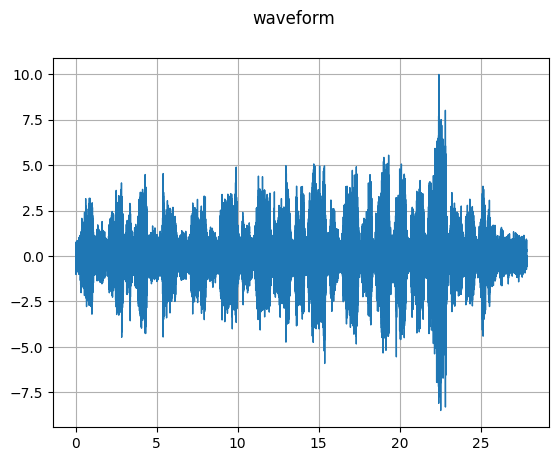

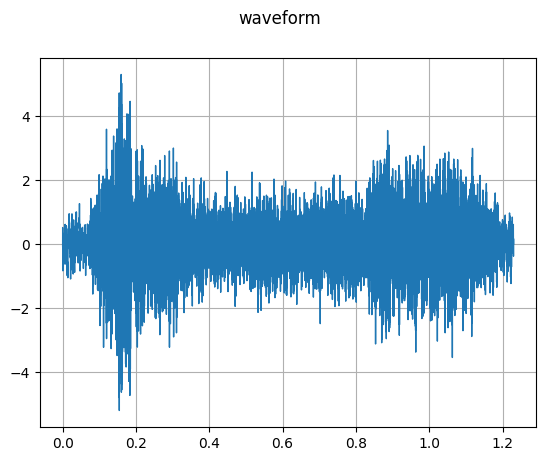

In [4]:
mu_display.plot_muaudio( audio[0], [0] )
mu_display.plot_muaudio( audio[1], [0] )

Certains signaux sont des séquences. Dans cet exemple nous devons considérer uniquement des "mots". Nous pouvons sélectionner des mots en filtrant la requête avec l'étiquette "Sound word" (identifiant 5):

In [5]:
session = AidbSession( dbhost='http://dbwelfare.biimea.io/', login='ailab', email='bruno.gas@biimea.com', password='#T;uZnQ5UJ_JC~&' )
session.open()
audio = session.load_labelized( label_id=15, limit=100, tags_id=5, channels=[1] )
session.close()

2023-03-06 16:08:22,182 [INFO]:  .Try connecting on endpoint database http://dbwelfare.biimea.io/...
2023-03-06 16:08:22,423 [INFO]:  .Got HTTP 200 status code from server
2023-03-06 16:08:22,423 [INFO]:  .Received CSRF token: MHZlsBP6xlbWOHj1wBTmWJT5OYmg6pQ1. Update session with
2023-03-06 16:08:22,424 [INFO]:  .Received session id: 8doxf8y79l20h4v5mm1ebx6vbm3g9vtx
2023-03-06 16:08:22,425 [INFO]:  .Successfully connected on http://dbwelfare.biimea.io/
2023-03-06 16:08:22,427 [INFO]:  .Downloading labelized audio files from http://dbwelfare.biimea.io/...
2023-03-06 16:08:22,482 [INFO]:  .Found 18 labelized audio files
2023-03-06 16:08:22,482 [INFO]:  .Limit is set to 100 audio files
2023-03-06 16:08:22,483 [INFO]:  .Downloading metadata for object 'sourcefile' [8146]...
2023-03-06 16:08:22,525 [INFO]:  Object sourcefile found with identifier [8146] 
2023-03-06 16:08:22,549 [INFO]:  .Downloading metadata for object 'sourcefile' [8146]...
2023-03-06 16:08:22,625 [INFO]:  Object sourcefil